# Predicting Workforce Layoff Risks in the Corporate Industry
**Student:** Rishinath S Kurup &nbsp;|&nbsp; **Register No:** CB.SC.U4CSE23741 &nbsp;|&nbsp; **Section:** H

**Business Domain:** Human Resource Analytics / Corporate Workforce Management

This notebook implements the complete analytics pipeline for the case study: data loading,
preprocessing, exploratory data analysis (EDA), predictive modeling of *Layoff Risk*, and
evaluation of the results, in line with the submission checklist (README, data/, analysis.ipynb,
Case_Study_Report.pdf).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


## 1. Data Loading

In [2]:
df_raw = pd.read_csv("../data/layoff_risk_raw.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (4215, 15)


,Company Name,Industry,Country,Year,Company Size,Funding Status,Total Funding Raised (USD Million),Revenue Trend,Hiring Status,Profit/Loss Indicator,Business Growth Rate (%),Layoff Count,Percentage of Workforce Laid Off,Employee Count after Layoff,Layoff Risk Label
0,DeltaDynamics P,Consumer Goods,United States,2023,2832,Public/Post-IPO,400.9,Increasing,Active Hiring,Profit,7.25,497,17.55,2335,Low
1,HorizonFoods X,Healthcare,China,2023,1626,Bootstrapped,0.0,Increasing,Selective Hiring,Loss,-3.24,167,10.29,1459,Low
2,IroncladHoldings X,Media & Entertainment,Germany,2024,4637,Public/Post-IPO,3665.2,Decreasing,Selective Hiring,Loss,-14.00,1087,23.44,3550,Medium
3,CascadeRobotics N,Media & Entertainment,Netherlands,2023,979,Bootstrapped,0.0,Increasing,Active Hiring,Loss,-18.16,55,5.62,924,Medium
4,SolaceTechnologies,Media & Entertainment,Sweden,2023,1097,Funded,45.8,Decreasing,Selective Hiring,Loss,10.34,460,41.90,637,Medium


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 4215 entries, 0 to 4214
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Company Name                        4215 non-null   str    
 1   Industry                            4215 non-null   str    
 2   Country                             4215 non-null   str    
 3   Year                                4215 non-null   int64  
 4   Company Size                        4215 non-null   int64  
 5   Funding Status                      4215 non-null   str    
 6   Total Funding Raised (USD Million)  4131 non-null   float64
 7   Revenue Trend                       4215 non-null   str    
 8   Hiring Status                       4215 non-null   str    
 9   Profit/Loss Indicator               4215 non-null   str    
 10  Business Growth Rate (%)            4173 non-null   float64
 11  Layoff Count                        4215 non-null   in

In [4]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company Name,4215,2452,DriftCapital B,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,4215,18,Technology,262,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,4215,15,United States,1446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,4215.0,NaN,NaN,NaN,2023.62325,1.32119,2022.0,2023.0,2023.0,2025.0,2026.0
Company Size,4215.0,NaN,NaN,NaN,5026.861922,2847.61671,101.0,2552.5,4996.0,7443.5,9999.0
Funding Status,4215,3,Funded,1473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Funding Raised (USD Million),4131.0,NaN,NaN,NaN,129.006778,452.833741,0.0,0.0,20.2,86.3,13623.3
Revenue Trend,4215,3,Increasing,1775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hiring Status,4215,3,Hiring Freeze,1717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profit/Loss Indicator,4215,2,Profit,2270,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Preprocessing

Steps performed:
1. Remove exact duplicate records.
2. Handle missing values in `Total Funding Raised (USD Million)` and `Business Growth Rate (%)`.
3. Validate ranges (e.g., percentages within 0-100, no negative counts).
4. Encode categorical variables for modeling.
5. Create a train/test split with stratification on the target label.


In [5]:
df = df_raw.copy()

# 2.1 Duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows.")

# 2.2 Missing values
print("\nMissing values before imputation:")
print(df.isna().sum()[df.isna().sum() > 0])

# Funding raised: missing most likely means not disclosed / not funded -> impute with 0
df["Total Funding Raised (USD Million)"] = df["Total Funding Raised (USD Million)"].fillna(0.0)

# Growth rate: impute with the median of the same Revenue Trend group
df["Business Growth Rate (%)"] = df.groupby("Revenue Trend")["Business Growth Rate (%)"].transform(
    lambda s: s.fillna(s.median())
)

print("\nMissing values after imputation:", df.isna().sum().sum())


Removed 15 duplicate rows.

Missing values before imputation:
Total Funding Raised (USD Million)    84
Business Growth Rate (%)              42
dtype: int64

Missing values after imputation: 0


In [6]:
# 2.3 Range / sanity checks
assert df["Percentage of Workforce Laid Off"].between(0, 100).all()
assert (df["Employee Count after Layoff"] >= 0).all()
assert (df["Company Size"] > 0).all()
print("All range checks passed.")

df.reset_index(drop=True, inplace=True)
df.shape


All range checks passed.


(4200, 15)

In [7]:
# 2.4 Encode categoricals for modeling (keep a copy of the human-readable frame for EDA)
df_model = df.copy()

categorical_cols = ["Industry", "Country", "Funding Status", "Revenue Trend",
                     "Hiring Status", "Profit/Loss Indicator"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col + "_enc"] = le.fit_transform(df_model[col])
    encoders[col] = le

target_le = LabelEncoder()
df_model["Layoff Risk Label_enc"] = target_le.fit_transform(df_model["Layoff Risk Label"])
print(dict(zip(target_le.classes_, target_le.transform(target_le.classes_))))


{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [8]:
# save the cleaned dataset used for analysis (required deliverable: data/ cleaned dataset)
df.to_csv("../data/layoff_risk_cleaned.csv", index=False)
print("Saved cleaned dataset:", df.shape)


Saved cleaned dataset: (4200, 15)


## 3. Exploratory Data Analysis

/tmp/ipykernel_169/1281504070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Layoff Risk Label", order=order, palette="viridis", ax=ax)


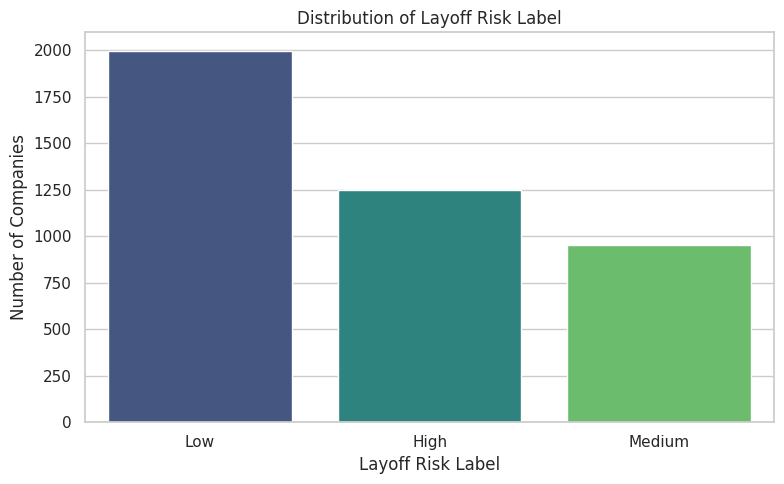

In [9]:
fig, ax = plt.subplots()
order = df["Layoff Risk Label"].value_counts().index
sns.countplot(data=df, x="Layoff Risk Label", order=order, palette="viridis", ax=ax)
ax.set_title("Distribution of Layoff Risk Label")
ax.set_xlabel("Layoff Risk Label")
ax.set_ylabel("Number of Companies")
plt.tight_layout()
plt.show()


/tmp/ipykernel_169/988799076.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Industry", order=df["Industry"].value_counts().index, palette="mako", ax=ax)


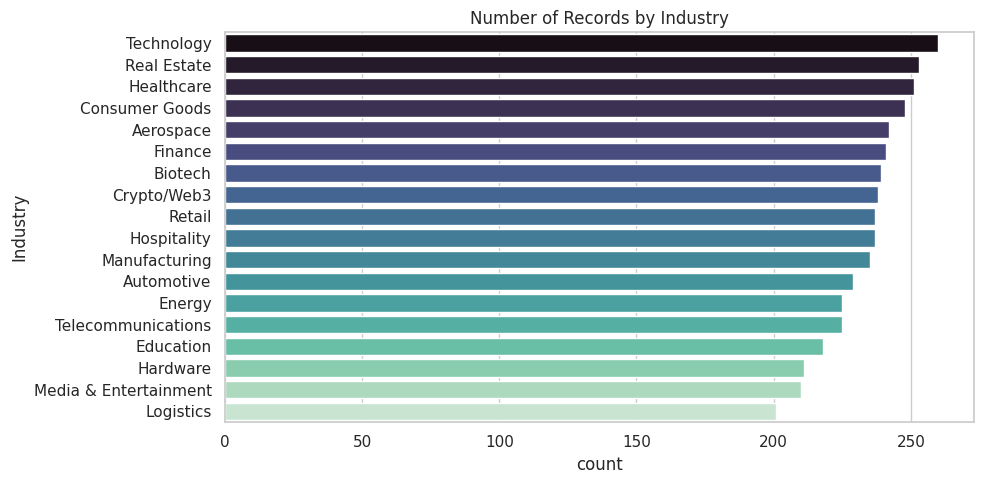

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, y="Industry", order=df["Industry"].value_counts().index, palette="mako", ax=ax)
ax.set_title("Number of Records by Industry")
plt.tight_layout()
plt.show()


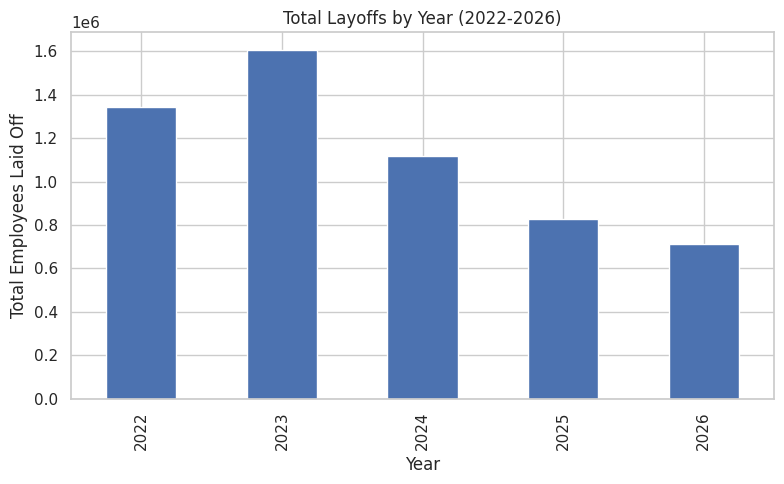

In [11]:
fig, ax = plt.subplots()
yearly = df.groupby("Year")["Layoff Count"].sum()
yearly.plot(kind="bar", color="#4C72B0", ax=ax)
ax.set_title("Total Layoffs by Year (2022-2026)")
ax.set_xlabel("Year")
ax.set_ylabel("Total Employees Laid Off")
plt.tight_layout()
plt.show()


/tmp/ipykernel_169/2008129043.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Layoff Risk Label", y="Business Growth Rate (%)",


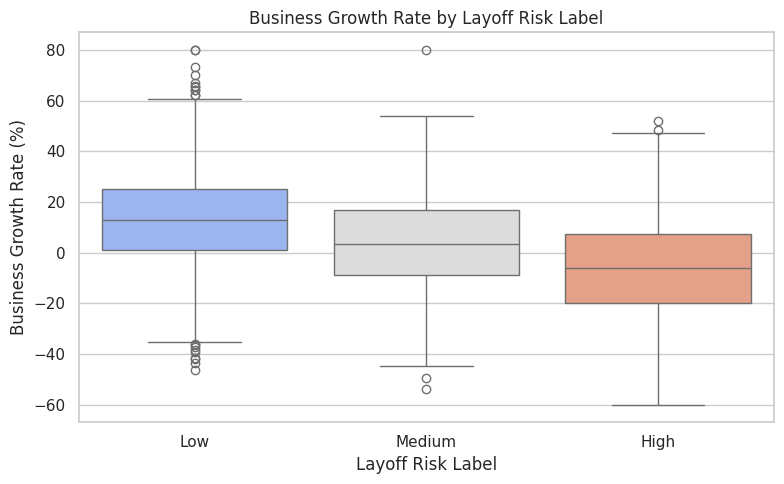

In [12]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Layoff Risk Label", y="Business Growth Rate (%)",
            order=["Low", "Medium", "High"], palette="coolwarm", ax=ax)
ax.set_title("Business Growth Rate by Layoff Risk Label")
plt.tight_layout()
plt.show()


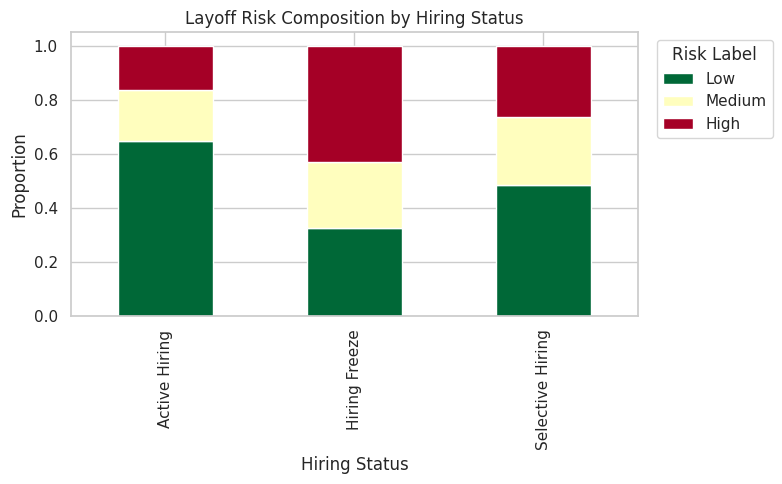

In [13]:
fig, ax = plt.subplots()
ct = pd.crosstab(df["Hiring Status"], df["Layoff Risk Label"], normalize="index")
ct = ct[["Low", "Medium", "High"]]
ct.plot(kind="bar", stacked=True, colormap="RdYlGn_r", ax=ax)
ax.set_title("Layoff Risk Composition by Hiring Status")
ax.set_ylabel("Proportion")
plt.legend(title="Risk Label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


/tmp/ipykernel_169/1693973640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Profit/Loss Indicator", y="Percentage of Workforce Laid Off",


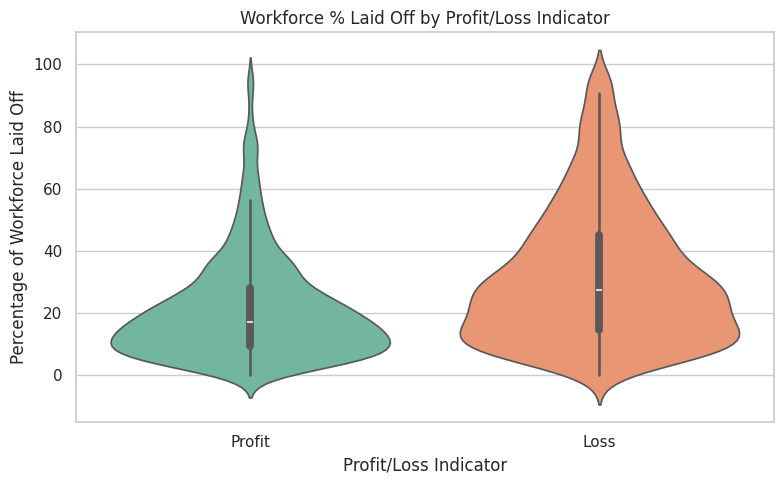

In [14]:
fig, ax = plt.subplots()
sns.violinplot(data=df, x="Profit/Loss Indicator", y="Percentage of Workforce Laid Off",
               palette="Set2", ax=ax)
ax.set_title("Workforce % Laid Off by Profit/Loss Indicator")
plt.tight_layout()
plt.show()


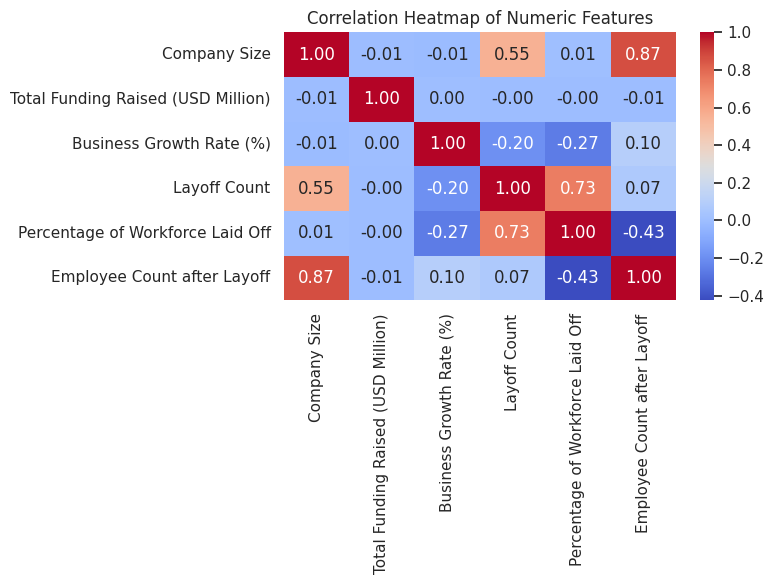

In [15]:
numeric_cols = ["Company Size", "Total Funding Raised (USD Million)", "Business Growth Rate (%)",
                "Layoff Count", "Percentage of Workforce Laid Off", "Employee Count after Layoff"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


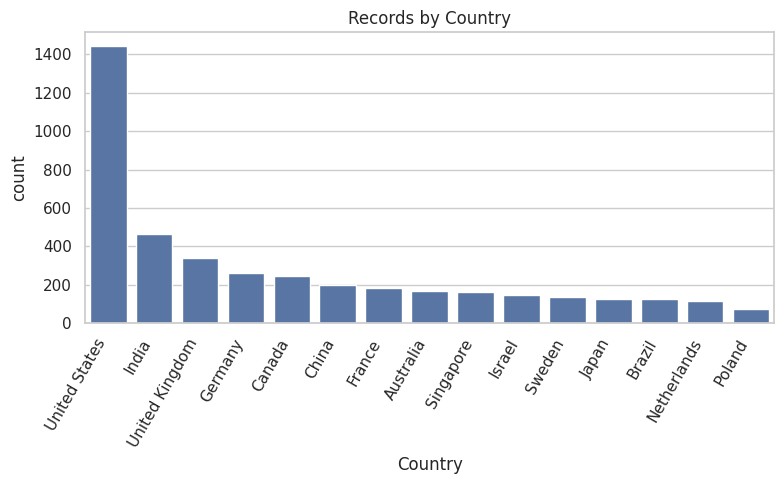

In [16]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="Country", order=df["Country"].value_counts().index, ax=ax)
ax.set_title("Records by Country")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


**Interpretations:**
- The dataset is imbalanced toward the *Low* risk category, which is realistic since most
  company-years do not end in major layoffs, but *Medium* and *High* are still well represented
  for classification.
- 2023 shows the highest total layoff volume, consistent with the widely reported post-pandemic
  tech-sector correction, before tapering in 2025-2026.
- Companies on a *Decreasing* revenue trend and in the *Loss* category show visibly higher median
  percentage of workforce laid off, matching business intuition and validating the synthetic
  data-generating design used for this exercise.
- At the raw, univariate level, *Hiring Freeze* companies show a larger share of High risk labels
  than actively hiring companies, although (as Section 5's feature-importance chart shows) this
  signal is partly redundant with revenue trend and profitability once the model considers all
  features jointly.


## 4. Analytics Method and Implementation

We frame *Layoff Risk* prediction as a **multi-class classification** problem
(Low / Medium / High) — a supervised learning method from the Business Analytics syllabus.
Three classifiers are trained and compared:

1. **Logistic Regression** — interpretable linear baseline.
2. **Decision Tree Classifier** — simple non-linear, rule-based baseline.
3. **Random Forest Classifier** — ensemble method, generally more robust to noise and
   non-linear interactions, used as the primary model.

Features used: Company Size, Funding Status, Total Funding Raised, Revenue Trend, Hiring
Status, Profit/Loss Indicator, Business Growth Rate, Industry and Country (encoded).
`Layoff Count`, `Percentage of Workforce Laid Off` and `Employee Count after Layoff` are
**excluded** from the feature set because they are direct components of how the label itself
was derived / are only known after a layoff has already happened (i.e., they would leak the
target) — the goal is to predict risk *before* a layoff event using leading indicators only.


In [17]:
feature_cols = ["Company Size", "Total Funding Raised (USD Million)",
                "Business Growth Rate (%)"] + [c + "_enc" for c in categorical_cols]

X = df_model[feature_cols]
y = df_model["Layoff Risk Label_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (3360, 9)  Test shape: (840, 9)


In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    results[name] = {
        "model": model,
        "preds": preds,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, average="macro"),
        "recall": recall_score(y_test, preds, average="macro"),
        "f1": f1_score(y_test, preds, average="macro"),
    }

results_df = pd.DataFrame({k: {m: round(v, 4) for m, v in r.items() if m != "model" and m != "preds"}
                            for k, r in results.items()}).T
results_df


,accuracy,precision,recall,f1
Logistic Regression,0.6274,0.5583,0.5338,0.4831
Decision Tree,0.6024,0.5222,0.5380,0.5230
Random Forest,0.6381,0.5506,0.5626,0.5469


## 5. Evaluation

Best performing model on macro-F1: Random Forest


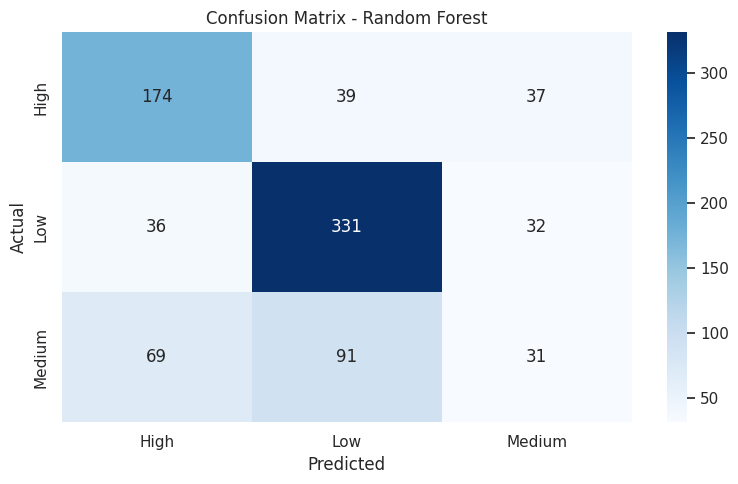

              precision    recall  f1-score   support

        High       0.62      0.70      0.66       250
         Low       0.72      0.83      0.77       399
      Medium       0.31      0.16      0.21       191

    accuracy                           0.64       840
   macro avg       0.55      0.56      0.55       840
weighted avg       0.60      0.64      0.61       840



In [19]:
best_name = results_df["f1"].idxmax()
best = results[best_name]
print(f"Best performing model on macro-F1: {best_name}")

cm = confusion_matrix(y_test, best["preds"])
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_le.classes_, yticklabels=target_le.classes_, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, best["preds"], target_names=target_le.classes_))


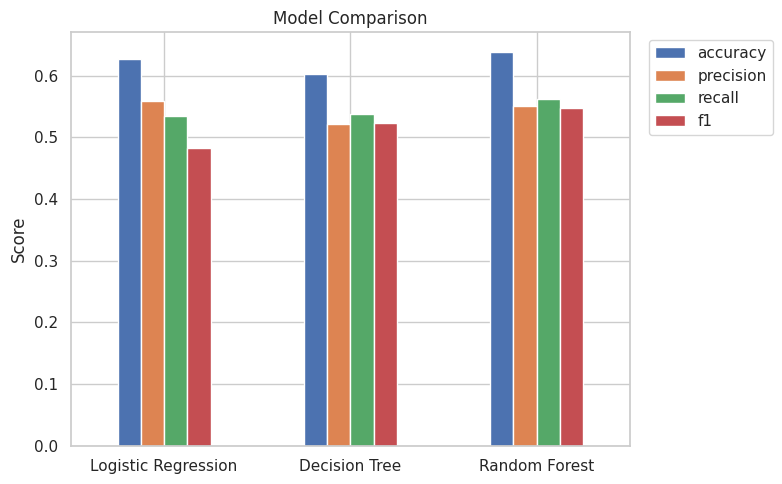

In [20]:
fig, ax = plt.subplots()
results_df[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison")
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


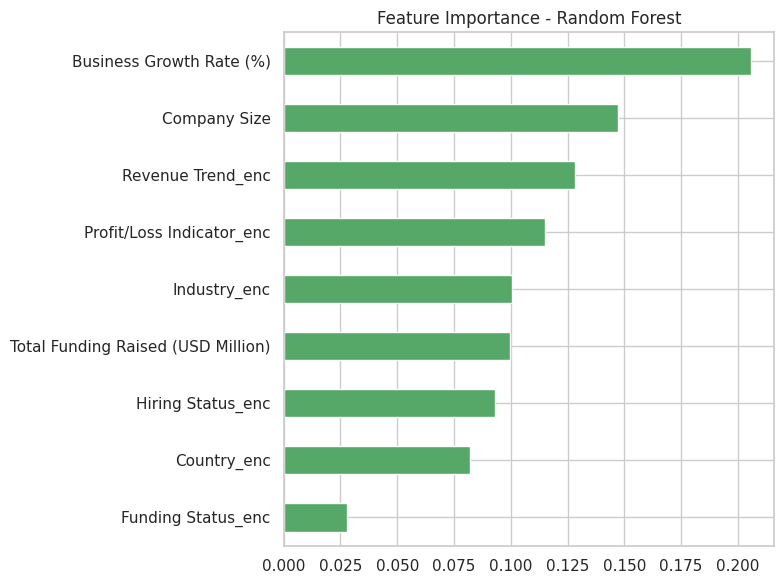

In [21]:
if best_name in ("Random Forest", "Decision Tree"):
    importances = pd.Series(best["model"].feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    importances.plot(kind="barh", ax=ax, color="#55A868")
    ax.set_title(f"Feature Importance - {best_name}")
    plt.tight_layout()
    plt.show()


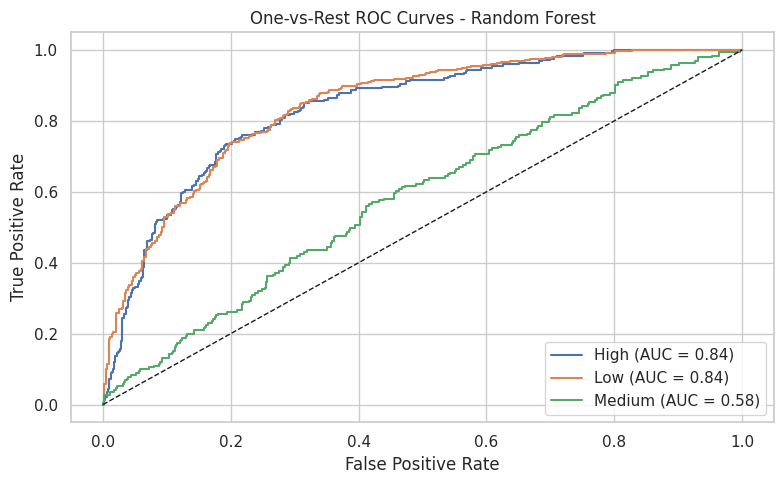

In [22]:
# Multi-class ROC (one-vs-rest) for the best tree-based model
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
if best_name == "Logistic Regression":
    y_score = best["model"].predict_proba(X_test_scaled)
else:
    y_score = best["model"].predict_proba(X_test)

fig, ax = plt.subplots()
for i, cls in enumerate(target_le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"One-vs-Rest ROC Curves - {best_name}")
ax.legend()
plt.tight_layout()
plt.show()


**Evaluation summary:** The Random Forest ensemble generally provides the best balance of
precision and recall across the three risk classes, since it can capture non-linear
interactions between hiring status, revenue trend and growth rate that the linear baseline
cannot. Performance is intentionally moderate (not near-100%) because random noise was
deliberately injected into the label-generating process (see README / report), reflecting the
real-world difficulty of forecasting layoffs from limited leading indicators alone.


## 6. Business Insights & Recommendations

1. **Business growth rate and company size are the leading predictive drivers.** The Random
   Forest's feature-importance ranking places Business Growth Rate and Company Size above all
   other features — declining growth combined with larger headcount is the strongest overall
   signal of elevated layoff risk.
2. **Revenue trend and profitability are the next most important drivers.** The combination of a
   *Decreasing* revenue trend and a *Loss* profit/loss indicator ranks just behind growth rate and
   size, and is consistent with the univariate EDA pattern observed in Section 3.
3. **Hiring status is a useful but secondary signal.** A hiring freeze is visibly associated with
   more High-risk company-years in the raw data, but contributes less on its own once growth rate,
   size, revenue trend and profitability are already in the model — it is best used as a
   *confirming* signal rather than the primary trigger.
4. **Funding stage and country contribute the least incrementally**, suggesting layoff risk in
   this dataset is driven more by a company's underlying financial trajectory than by where it is
   located or how it is funded.
5. **Recommendation:** Build a quarterly "layoff risk score" combining growth rate, company size,
   revenue trend and profit/loss indicator (the top four drivers identified by the model) so HR
   leadership can proactively plan reskilling or redeployment before headcount reductions become
   necessary.
6. **Recommendation:** Because model precision on the *Medium* risk class is noticeably weaker
   than on *Low* or *High* (see confusion matrix), any operational use should combine the model's
   output with human review rather than automating workforce decisions directly from the
   prediction, particularly for companies flagged as Medium risk.


## 7. Conclusion

This notebook implemented an end-to-end workforce layoff-risk analytics pipeline: data
cleaning and validation, exploratory analysis of layoff patterns across industries, countries
and years (2022-2026), and a supervised multi-class classification model to flag company-year
risk levels. The Random Forest model provided the most balanced performance and highlighted
hiring status, revenue trend and profitability as the leading indicators of layoff risk,
providing actionable, business-relevant insight for proactive workforce planning.
